In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA LOADING AND CLEANING

In [2]:
df = pd.read_csv('netflix_titles.csv')

In [3]:
df.shape

(8807, 12)

In [10]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
df['director'] = df['director'].fillna(df['director'].mode()[0])
df.dropna(subset=['country', 'cast', 'rating', 'duration', 'date_added'], inplace=True)


In [24]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [25]:
df.shape

(7290, 12)

## EDA

In [81]:
df.describe()

,release_year,year_added
count,7290.000000,7290.000000
mean,2013.698903,2018.819616
std,8.862822,1.554153
min,1942.000000,2008.000000
25%,2013.000000,2018.000000
50%,2017.000000,2019.000000
75%,2019.000000,2020.000000
max,2021.000000,2021.000000


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7290 entries, 1 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7290 non-null   object        
 1   type          7290 non-null   object        
 2   title         7290 non-null   object        
 3   director      7290 non-null   object        
 4   cast          7290 non-null   object        
 5   country       7290 non-null   object        
 6   date_added    7290 non-null   datetime64[ns]
 7   release_year  7290 non-null   int64         
 8   rating        7290 non-null   object        
 9   duration      7290 non-null   object        
 10  listed_in     7290 non-null   object        
 11  description   7290 non-null   object        
 12  year_added    7290 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(10)
memory usage: 797.3+ KB


In [26]:
df['type'].unique()

array(['TV Show', 'Movie'], dtype=object)

In [34]:
tv_show = len(df[df['type'] == 'TV Show'])
movie = len(df[df['type'] == 'Movie'])

In [ ]:
## Number of TV Shows vs movies
tv_show, movie

(2013, 5277)

In [ ]:
## Countries producing most of the content
df['country'].value_counts().head(20)

United States                    2479
India                             940
United Kingdom                    350
Japan                             238
South Korea                       196
Canada                            162
Spain                             127
France                            106
Egypt                             105
Turkey                            105
Mexico                            102
Nigeria                            93
Taiwan                             81
Indonesia                          78
Philippines                        75
Australia                          75
United States, Canada              72
United Kingdom, United States      71
Brazil                             68
China                              66
Name: country, dtype: int64

In [ ]:
##Content growth
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df.groupby('year_added')['title'].count()

year_added
2008       1
2009       2
2010       1
2011      13
2012       3
2013      11
2014      20
2015      70
2016     358
2017     989
2018    1404
2019    1722
2020    1640
2021    1056
Name: title, dtype: int64

In [ ]:
##Rating Distribution
df['rating'].value_counts()

TV-MA       2657
TV-14       1755
R            779
TV-PG        653
PG-13        470
PG           275
TV-Y7        222
TV-Y         209
TV-G         158
NR            62
G             40
TV-Y7-FV       4
NC-17          3
UR             3
Name: rating, dtype: int64

## VISUALIZATION

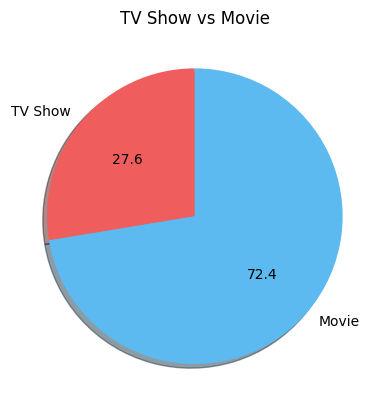

In [56]:
category = ['TV Show', 'Movie']
y = [tv_show, movie]
plt.title('TV Show vs Movie')
plt.pie(y, labels=category, autopct= '%1.1f', shadow= True, startangle=90, colors=['#f05d5d', '#5dbaf0'])
plt.show()

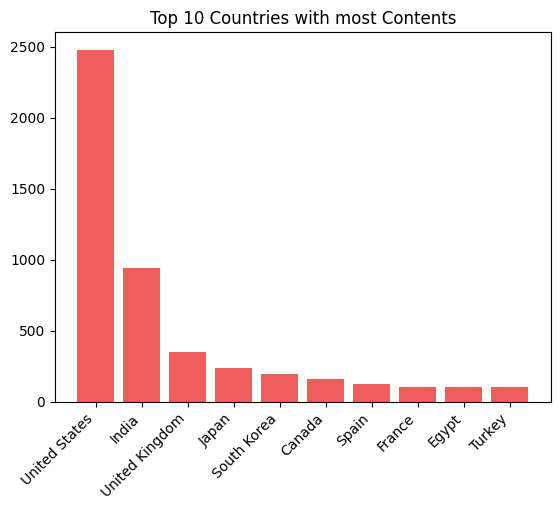

In [74]:
country_content = df['country'].value_counts().head(10)
index = country_content.index
values = country_content.values

plt.title('Top 10 Countries with most Contents')
plt.xticks(rotation = 45, ha = 'right')
plt.bar(index, values, color = '#f05d5d')
plt.show()

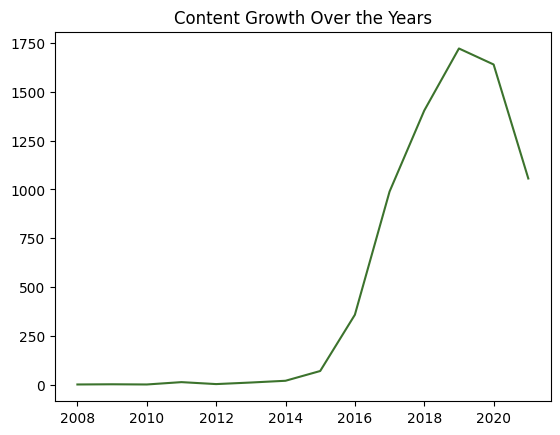

In [80]:
content_count = df.groupby('year_added')['title'].count()
index = content_count.index
values = content_count.values

plt.title('Content Growth Over the Years')
plt.plot(index, values, color = '#3c732d')
plt.show()

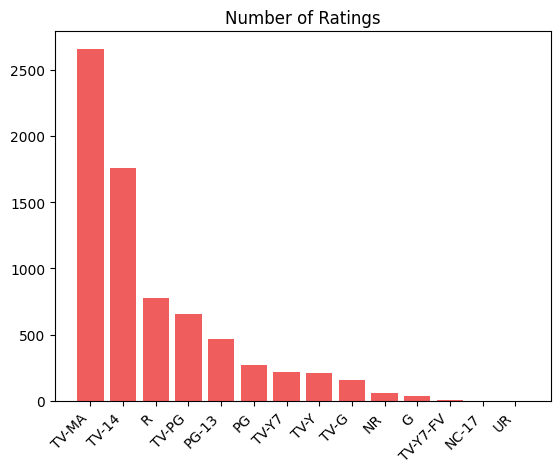

In [78]:
rating_numbers = df['rating'].value_counts()
index = rating_numbers.index
values = rating_numbers.values

plt.title('Number of Ratings')
plt.xticks(rotation = 45, ha = 'right')
plt.bar(index, values, color = '#f05d5d')
plt.show()

## INSIGHTS AND CONCLUSIONS

Netflix library consists of significantly more Movies than TV Shows,
with movies making up around 70% of the total content.

The United States dominates Netflix content production by a huge margin,
followed by India and the United Kingdom, reflecting Netflix's focus
on English language and Bollywood content.

TV-MA is the most common rating on Netflix, meaning the platform heavily
targets adult audiences. TV-14 is the second most common, suggesting
teenagers are the next biggest target group.

Family friendly content like G and PG rated titles make up a very
small portion of the library, showing Netflix is not primarily
focused on children's content.